In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LogNorm
from matplotlib.ticker import PercentFormatter

# 0. Import Datasets:

In [2]:
customers_db = pd.read_csv("data/DM_AIAI_CustomerDB.csv", sep=",", index_col=0)
flights_db = pd.read_csv("data/DM_AIAI_FlightsDB.csv", sep=",", index_col=0)

In [3]:
customers_db.head()

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion


In [4]:
customers_db.shape

(16921, 20)

In [5]:
flights_db.head()

,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
Loyalty#,,,,,,,,,
413052,2021,12,12/1/2021,2.0,2.0,9384.0,938.0,0.0,0.0
464105,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
681785,2021,12,12/1/2021,10.0,3.0,14745.0,1474.0,0.0,0.0
185013,2021,12,12/1/2021,16.0,4.0,26311.0,2631.0,3213.0,32.0
216596,2021,12,12/1/2021,9.0,0.0,19275.0,1927.0,0.0,0.0


In [6]:
flights_db.shape

(608436, 9)

- **Customers database has 16,921 rows and 20 columns**
- **flights database has 608,436 rows and 9 columns**

# 1. Analysis of each table separately:

## 1.1. FlightsDB:

### 1.1.3. Descriptives:

In [7]:
cols_flights = flights_db.columns.values
print(cols_flights)

['Year' 'Month' 'YearMonthDate' 'NumFlights' 'NumFlightsWithCompanions'
 'DistanceKM' 'PointsAccumulated' 'PointsRedeemed'
 'DollarCostPointsRedeemed']


Remove Loyalty# from the index and make it a column:

In [8]:
flights_db = flights_db.reset_index().rename(columns={'index': 'Loyalty#'})

In [9]:
flights_db.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loyalty#,608436.0,NaN,NaN,NaN,550037.873084,258935.180575,100018.0,326961.0,550834.0,772194.0,999986.0
Year,608436.0,NaN,NaN,NaN,2020.0,0.816497,2019.0,2019.0,2020.0,2021.0,2021.0
Month,608436.0,NaN,NaN,NaN,6.5,3.452055,1.0,3.75,6.5,9.25,12.0
YearMonthDate,608436,36,12/1/2021,16901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumFlights,608436.0,NaN,NaN,NaN,3.908107,5.057889,0.0,0.0,0.0,7.2,21.0
NumFlightsWithCompanions,608436.0,NaN,NaN,NaN,0.983944,2.003785,0.0,0.0,0.0,0.9,11.0
DistanceKM,608436.0,NaN,NaN,NaN,7939.341419,10260.421873,0.0,0.0,856.4,15338.175,42040.0
PointsAccumulated,608436.0,NaN,NaN,NaN,793.777781,1025.918521,0.0,0.0,85.275,1533.7125,4204.0
PointsRedeemed,608436.0,NaN,NaN,NaN,235.251678,983.233374,0.0,0.0,0.0,0.0,7496.0
DollarCostPointsRedeemed,608436.0,NaN,NaN,NaN,2.324835,9.725168,0.0,0.0,0.0,0.0,74.0


**Population size = 605,533 records**

---

**Loyalty#:**
- 605,533 rows and 16,737 unique.

**Year:**
- Range: 2019-2021
- Pandemic years
- Implication: Years are evenly spread. 


**Month:**
- Range: 1-12; quartiles: 4 / 7 / 10; mean ≈ 6.50.
- Implication: Months are evenly spread. 

**YearMonthDate:**
- Range: 2019-01-01 to 2021-12-01

**NumFlights:**
- Strong right-skewed and sparse. 
- Fractional values. Number of Flights are counts, so they should be integers. 

**NumFlightsWithCompanions:**
- Strong right-skewed with many zeros. 
- Fractional values. Number of flights With Companions are counts, so they should be integers. 

**DistanceKM:**
- Mean = 7977.4; median = 993.6; 75% ≈ 15,408.9; max = 42,040;
- Implication: Strong right-skewed distribution with a long tail to very large values. 

**PointsAccumulated:**
- Heavy right-skewed wit many zeros and low values. 

**PointsRedeemed:**
- Extreme zero-inflated. Occurs in sporadic spikes rather than steadily month-to-month.

**DollarCostPointsRedeemed:**
- Mirrors PointsRedeemed: Mostly zeros, with small positive values. 

In [10]:
flights_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608436 entries, 0 to 608435
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Loyalty#                  608436 non-null  int64  
 1   Year                      608436 non-null  int64  
 2   Month                     608436 non-null  int64  
 3   YearMonthDate             608436 non-null  object 
 4   NumFlights                608436 non-null  float64
 5   NumFlightsWithCompanions  608436 non-null  float64
 6   DistanceKM                608436 non-null  float64
 7   PointsAccumulated         608436 non-null  float64
 8   PointsRedeemed            608436 non-null  float64
 9   DollarCostPointsRedeemed  608436 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 46.4+ MB


**Wrong Datatypes:**
- **Loyalty#** - From int64 to string
- **YearMonthDate** - From object to datetime
- **NumFlights, NumFlightsWithCompanions** - From float to int

### 1.1.1. Datatypes:

In [11]:
# Convert loyalty# to string:
flights_db["Loyalty#"] = flights_db["Loyalty#"].astype("string")

# Convert YearMonthDate to datetime:
flights_db['YearMonthDate'] = flights_db['YearMonthDate'].apply(lambda s: pd.to_datetime(s, errors='coerce'))

In [12]:
flights_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608436 entries, 0 to 608435
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Loyalty#                  608436 non-null  string        
 1   Year                      608436 non-null  int64         
 2   Month                     608436 non-null  int64         
 3   YearMonthDate             608436 non-null  datetime64[ns]
 4   NumFlights                608436 non-null  float64       
 5   NumFlightsWithCompanions  608436 non-null  float64       
 6   DistanceKM                608436 non-null  float64       
 7   PointsAccumulated         608436 non-null  float64       
 8   PointsRedeemed            608436 non-null  float64       
 9   DollarCostPointsRedeemed  608436 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(2), string(1)
memory usage: 46.4 MB


### 1.1.2. Duplicates:

In [13]:
nr_full_duplicates_flights = flights_db.duplicated(keep=False).sum()
total_rows = len(flights_db)
pct_full_duplicates = (nr_full_duplicates_flights / total_rows) * 100

print(f"Total number of full duplicates: {nr_full_duplicates_flights} "
      f"({pct_full_duplicates:.2f}%)")

Total number of full duplicates: 5778 (0.95%)


**There are 5778 (0.95%) full duplicate records, including Loyalty#**

Since these duplicate records hold no additional information, we'll delete them.

In [14]:
cols_all = list(flights_db.columns)
flights_db = flights_db.drop_duplicates(subset=cols_all, keep='first').copy()

In [15]:
nr_full_duplicates_flights = flights_db.duplicated(keep=False).sum()
total_rows = len(flights_db)
pct_full_duplicates = (nr_full_duplicates_flights / total_rows) * 100

print(f"Total number of full duplicates: {nr_full_duplicates_flights} "
      f"({pct_full_duplicates:.2f}%)")

Total number of full duplicates: 0 (0.00%)


### 1.1.3. Missing Values:

In [16]:
total_missing = flights_db.isna().sum().sum()
total_missing_pct = (total_missing / flights_db.size) * 100  

print(f"Total missing values: {total_missing:,} ({total_missing_pct:.2f}%) ")

missing_by_col = (
    flights_db.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda d: d["missing_count"] / len(flights_db) * 100)
    .sort_values("missing_pct", ascending=False)
)

print("\nMissing values by column (count and % of rows):")
print(missing_by_col)

Total missing values: 0 (0.00%) 

Missing values by column (count and % of rows):
                          missing_count  missing_pct
Loyalty#                              0          0.0
Year                                  0          0.0
Month                                 0          0.0
YearMonthDate                         0          0.0
NumFlights                            0          0.0
NumFlightsWithCompanions              0          0.0
DistanceKM                            0          0.0
PointsAccumulated                     0          0.0
PointsRedeemed                        0          0.0
DollarCostPointsRedeemed              0          0.0


**There are no missing values.**

### 1.1.4. Unique Values:

In [17]:
for column in flights_db.columns:
    unique_values = flights_db[column].unique()
    unique_values_num = flights_db[column].nunique()
    print(f"Unique values in '{column}':")
    print(unique_values)
    print(f"Number of unique values in '{column}':")
    print(unique_values_num)
    
    print()

Unique values in 'Loyalty#':
<StringArray>
['413052', '464105', '681785', '185013', '216596', '486956', '247514',
 '711864', '721372', '762715',
 ...
 '685375', '947026', '113839', '733903', '330947', '580586', '315014',
 '144328', '179042', '854855']
Length: 16737, dtype: string
Number of unique values in 'Loyalty#':
16737

Unique values in 'Year':
[2021 2020 2019]
Number of unique values in 'Year':
3

Unique values in 'Month':
[12  6  5  4  3  2  1 11 10  9  8  7]
Number of unique values in 'Month':
12

Unique values in 'YearMonthDate':
<DatetimeArray>
['2021-12-01 00:00:00', '2020-06-01 00:00:00', '2020-05-01 00:00:00',
 '2020-04-01 00:00:00', '2020-03-01 00:00:00', '2020-02-01 00:00:00',
 '2020-01-01 00:00:00', '2021-11-01 00:00:00', '2021-10-01 00:00:00',
 '2021-06-01 00:00:00', '2021-09-01 00:00:00', '2021-05-01 00:00:00',
 '2021-04-01 00:00:00', '2021-08-01 00:00:00', '2021-07-01 00:00:00',
 '2021-03-01 00:00:00', '2021-02-01 00:00:00', '2021-01-01 00:00:00',
 '2020-12-01 00:00:

- **Numflights and NumFlightsWithCompanions should be integer values**
- **No other inconsistency was found**

### 1.1.4. Data inconsistencies:

### Check if YearMonthDate is consistent with Year, Month:

In [18]:
parsed = pd.to_datetime(flights_db['YearMonthDate'], errors='coerce', dayfirst=False)
expected = pd.to_datetime({'year': flights_db['Year'], 'month': flights_db['Month'], 'day': 1})

pct_mismatch = (~parsed.eq(expected)).mean() * 100
total = len(flights_db)

print(f"Percentage of mismatches: {pct_mismatch:.2f}% ")


Percentage of mismatches: 0.00% 


### Check if NumFlightsWithCompanions is consistent with NumFlights:

In [19]:
mask = flights_db['NumFlightsWithCompanions'] > flights_db['NumFlights']
pct_mismatch = mask.mean() * 100
total = len(flights_db)

print(f"Percentage of mismatches: {pct_mismatch:.2f}% ")

Percentage of mismatches: 0.00% 


### Consistency checks between flights, distance, and points:

In [20]:
# NumFlights == 0 but has distance > 0 or points > 0
mask_A = (flights_db['NumFlights'] == 0) & (
    (flights_db['DistanceKM'] > 0) | (flights_db['PointsAccumulated'] > 0)
)

# NumFlights > 0 but distance == 0 or points == 0
mask_B = (flights_db['NumFlights'] > 0) & (
    (flights_db['DistanceKM'] == 0) | (flights_db['PointsAccumulated'] == 0)
)

total = len(flights_db)
count_A, count_B = mask_A.sum(), mask_B.sum()
pct_A, pct_B = (count_A / total) * 100, (count_B / total) * 100
count_any = (mask_A | mask_B).sum()
pct_any = (count_any / total) * 100

print(f"Flights=0 & (distance>0 or points>0): {pct_A:.2f}% ({count_A}/{total})")
print(f"Flights>0 & (distance=0 or points=0): {pct_B:.2f}% ({count_B}/{total})")

Flights=0 & (distance>0 or points>0): 0.97% (5901/605533)
Flights>0 & (distance=0 or points=0): 0.00% (0/605533)


Let's separate mismatches when Flights = 0

In [21]:
f0 = flights_db['NumFlights'] == 0
d_pos = flights_db['DistanceKM'] > 0
p_pos = flights_db['PointsAccumulated'] > 0

case_dist = f0 & d_pos                
case_points = f0 & p_pos              
case_both = f0 & d_pos & p_pos        
case_union = case_dist | case_points  

total = len(flights_db)

cnt_dist = case_dist.sum()
cnt_points = case_points.sum()
cnt_both = case_both.sum()
cnt_union = case_union.sum()

print(f"Flights=0 & Distance>0: {cnt_dist/total*100:.2f}% ({cnt_dist}/{total})")
print(f"Flights=0 & Points>0:   {cnt_points/total*100:.2f}% ({cnt_points}/{total})")
print(f"Overlap (both):         {cnt_both/total*100:.2f}% ({cnt_both}/{total})")


Flights=0 & Distance>0: 0.97% (5901/605533)
Flights=0 & Points>0:   0.97% (5901/605533)
Overlap (both):         0.97% (5901/605533)


**There are 5901 (0.97%) of records in which NumFlights = 0 with Distance>0 and Points>0.**

### 1.1.5. Feature Engineering:

#### 1.1.5.1. avg_distance_per_flight:

In [22]:
flights_db['avg_distance_per_flight'] = (
    flights_db['DistanceKM'] / flights_db['NumFlights'].replace(0, np.nan)
).fillna(0.0)

#### 1.1.5.2. companion_share:

Group/ Household behavior. 

In [23]:
flights_db['companion_share'] = (
    flights_db['NumFlightsWithCompanions'] / flights_db['NumFlights'].replace(0, np.nan)
).fillna(0.0)

### 1.1.6. Visualizations:

#### 1.1.6.1 Univariate Analysis:

##### 1.1.6.1.1. Metric Features:

In [24]:
metric_features = ["NumFlights", "NumFlightsWithCompanions", "DistanceKM", "PointsAccumulated", "PointsRedeemed", "DollarCostPointsRedeemed", "avg_distance_per_flight", "companion_share"]
discrete_time_features = ["Year", "Month"]
continuous_time_features = ["YearMonth"]
numeric_features = metric_features + discrete_time_features 
all_numeric_features = numeric_features + continuous_time_features

In [25]:
def plot_histograms_side_by_side(df, cols, bins=30, figsize=(12, 4)):
    
    n = len(cols)
    if n == 0:
        return

    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0], figsize[1] * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, c in enumerate(cols):
        ax = axes[i]
        s = df[c]  
        nan_count = s.isna().sum()
        total = len(s)

        ax.hist(s, bins=bins, edgecolor="black")  
        ax.set_title(f"Histogram of {c}")
        ax.set_xlabel(c)
        ax.set_ylabel("Frequency")
        ax.grid(alpha=0.25)
        ax.text(
            0.99, 0.95,
            f"NaNs: {nan_count/total*100:.2f}%",
            transform=ax.transAxes, ha="right", va="top"
        )

    plt.tight_layout()
    plt.show()

In [26]:
def plot_histograms_side_by_side_excluded_zeros(df, cols, bins=30, figsize=(12, 4)):
    n = len(cols)
    if n == 0:
        return

    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0], figsize[1] * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, c in enumerate(cols):
        ax = axes[i]
        s = df[c]
        nan_count = s.isna().sum()
        total = len(s)

        # Exclude zeros from the histogram
        s_nonzero = s[(s != 0) & (~s.isna())]

        if s_nonzero.empty:
            ax.axis("off")
            ax.text(0.5, 0.5, f"{c}\n(all values are 0 or NaN)",
                    ha="center", va="center", fontsize=10)
            continue

        ax.hist(s_nonzero, bins=bins, edgecolor="black")
        ax.set_title(f"Histogram of {c} (zeros excluded)")
        ax.set_xlabel(c)
        ax.set_ylabel("Frequency")
        ax.grid(alpha=0.25)
        ax.text(
            0.99, 0.95,
            f"NaNs: {nan_count/total*100:.2f}%",
            transform=ax.transAxes, ha="right", va="top"
        )

    # Hide any leftover axes if cols is odd
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

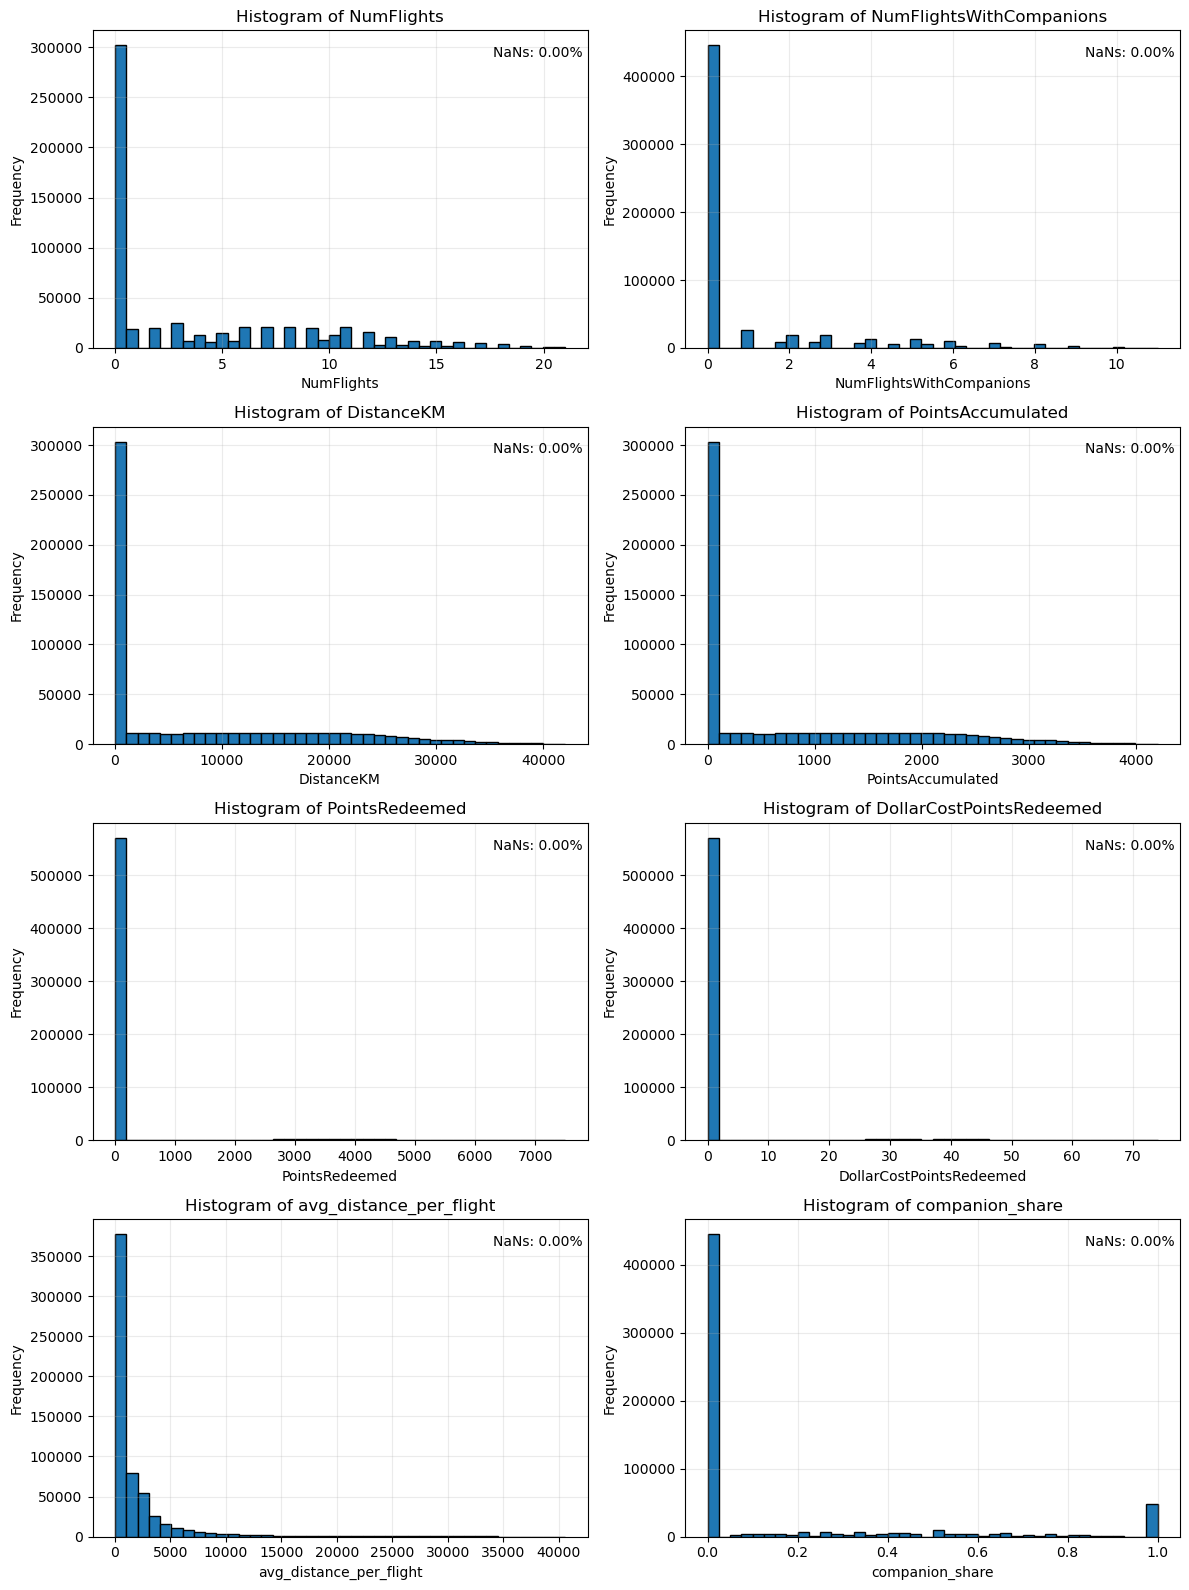

In [27]:
plot_histograms_side_by_side(flights_db, metric_features, bins=40)

Since all features have a huge spike at zero, we decided to plot all features excluding zero to better analyze the distribution.

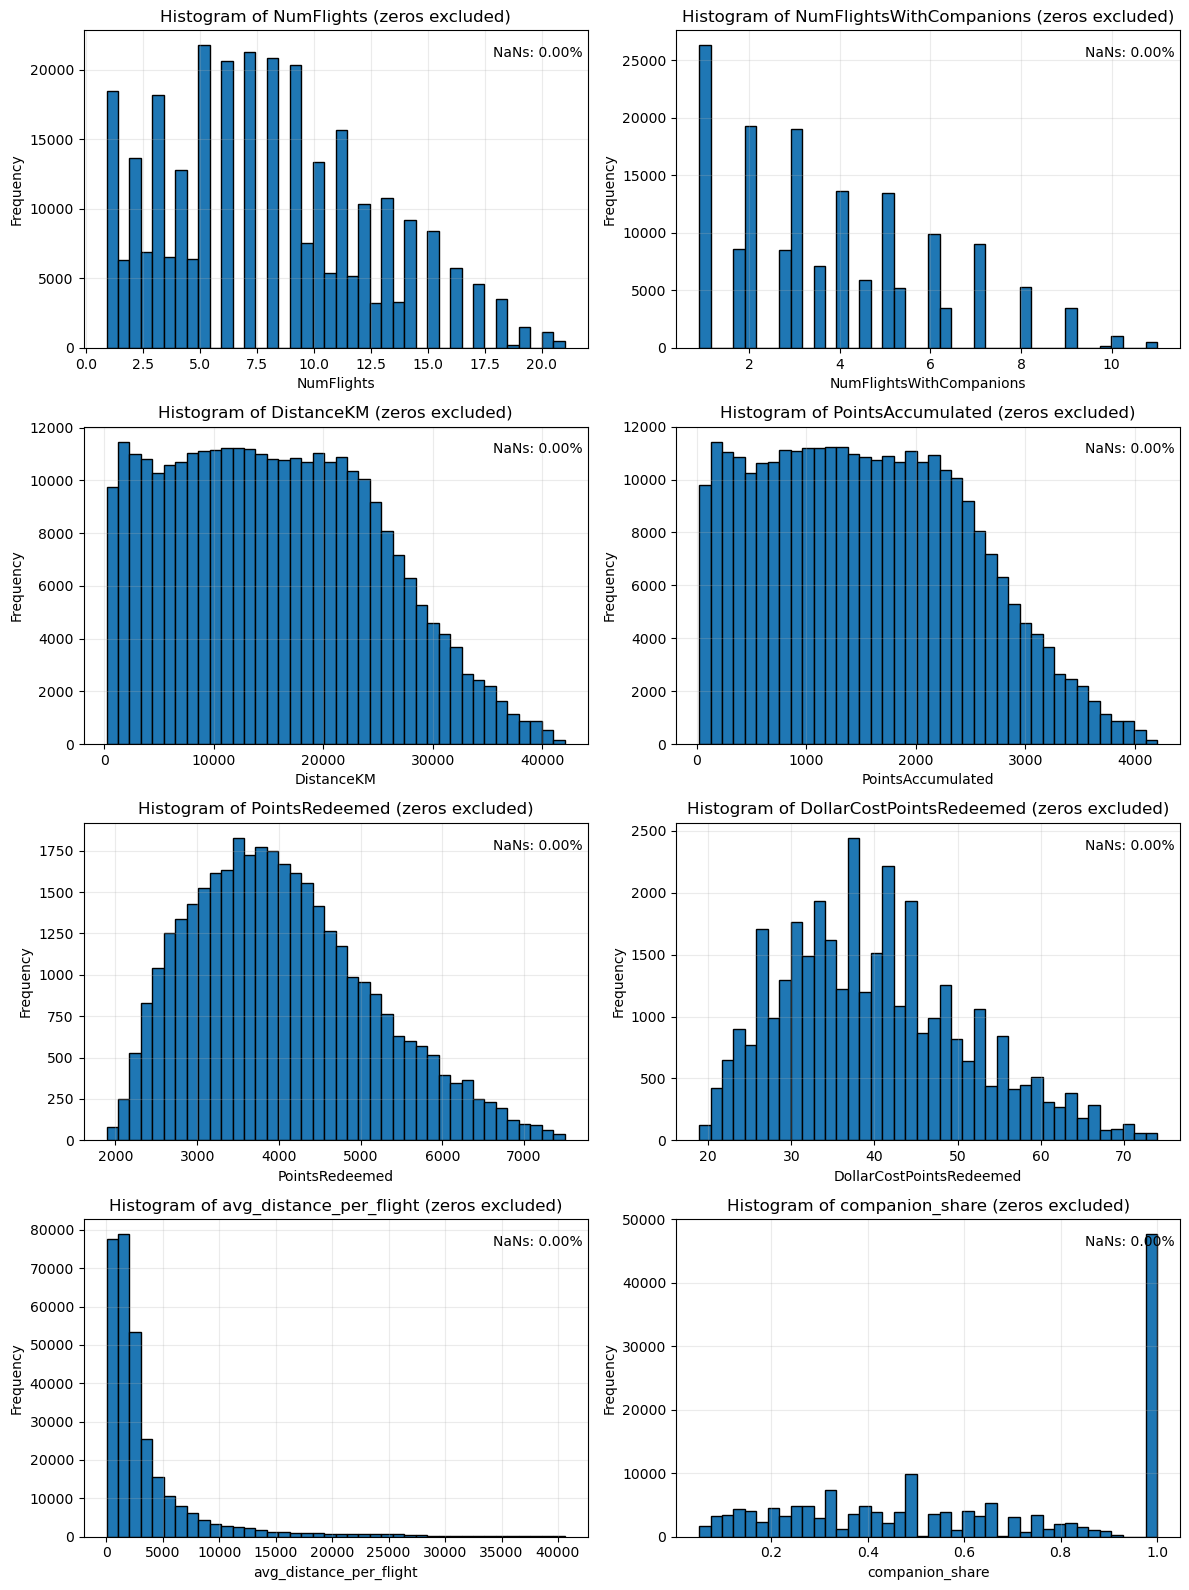

In [28]:
plot_histograms_side_by_side_excluded_zeros(flights_db, metric_features, bins=40)

**NumFlights:** 
- Huge spike at zero: Most months have no flights. 
- Long declining right tail from 0.9 up to ~21. 

**NumFlightsWithCompanions:** 
- Huge spike at zero, even higher than NumFlights. 
- Right-skewed tail to ~11. Mass in the 1-4 range.

**DistanceKM:** 
- Most mass at zero: inactive months. 
- Very long right-tail to ~42 Km.
- Broad plateau up to ~20k, then a steady decline into a long tail.
- Shape is strongly right-skewed even after removing zeros.

**PointsAccumulated:** 
- Shape mirrors DistanceKM distribuiton: big spike at 0, right tail. 

**PointsRedeemed:** 
- Extreme zero-inflation with a thin right tail to ~7,500 points. 

**DollarCostPointsRedeemed:** 
- Identical pattern to points redeemed. Extreme zero-inflation with a thin right tail with values to ~ $70-$74. 

**avg_distance_per_flight:** 
- Right-skewed distribution: Mass near low values (<2,500 Km), with a long tail and some extremes. 

**companion_share:** 
- Most months have no companions. 
- Companions, when present, many months are all-companion (share =1). 
- Indicates two behaviors: solo months vs fully accompanied months, with fewer mixed cases.

**OVERALL INTERPREATION:**
- Strong inactivity. Most customer-months show no activity, when activity happens, it's episodic and heavy tailed. 
- **PointsAccumulated** tracks **DistanceKM** almost exactly. Might be redundant. 
- **DollarCostPointsRedeemed** tracks **PointsRedeemed**almost exactly. Might be redundant. 
- Most months have no companions. Companions, when present, many months are all-companion (share =1). Helpful for segmentation: Solo vs Group travelers. 

Let's understand customer's flight activity:

In [29]:
id_col = "Loyalty#"   
features = [
    "NumFlights",
    "NumFlightsWithCompanions",
    "DistanceKM",
    "PointsAccumulated",
    "PointsRedeemed",
    "DollarCostPointsRedeemed",
]
na_is_zero = False  

df = flights_db.copy()  
X = df[features].astype(float)

zero_mask = (X.fillna(0) == 0) if na_is_zero else (X == 0)

df_flags = df.assign(
    all_zero = zero_mask.all(axis=1),
    any_zero = zero_mask.any(axis=1),
    any_nonzero = X.fillna(0).ne(0).any(axis=1),
)

stage1 = (
    df_flags
    .groupby(id_col, as_index=False)
    .agg(
        rows_total      = (id_col, "count"),
        rows_any_zero   = ("any_zero", "sum"),
        rows_all_zero   = ("all_zero", "sum"),
    )
)
stage1["rows_partial_zero"] = stage1["rows_any_zero"] - stage1["rows_all_zero"]
stage1["p_any_zero"]        = stage1["rows_any_zero"]   / stage1["rows_total"]
stage1["p_all_zero"]        = stage1["rows_all_zero"]   / stage1["rows_total"]
stage1["p_partial_zero"]    = stage1["rows_partial_zero"]/ stage1["rows_total"]


cust_summary = (
    df_flags
    .groupby(id_col, as_index=False)
    .agg(
        has_all_zero_row    = ("all_zero", "any"),
        has_any_nonzero_row = ("any_nonzero", "any"),
    )
)

customers_always_all_zero = cust_summary.query("has_all_zero_row and not has_any_nonzero_row")[id_col].tolist()
customers_mixed           = cust_summary.query("has_all_zero_row and has_any_nonzero_row")[id_col].tolist()
customers_never_all_zero  = cust_summary.query("~has_all_zero_row")[id_col].tolist()


In [30]:
total_customers = cust_summary.shape[0]
n_always = len(customers_always_all_zero)
n_mixed  = len(customers_mixed)
n_never  = len(customers_never_all_zero)

print(f"Total customers: {total_customers}")
print(f"- Always all-zero only: {n_always} ({(n_always/total_customers):.1%})")
print(f"- Mixed (all-zero + some activity): {n_mixed} ({(n_mixed/total_customers):.1%})")
print(f"- Never all-zero: {n_never} ({(n_never/total_customers):.1%})")


Total customers: 16737
- Always all-zero only: 1497 (8.9%)
- Mixed (all-zero + some activity): 15240 (91.1%)
- Never all-zero: 0 (0.0%)


**- There are 8.9% of customers that has no flight activity. These may represent new customers.**

**- Most of our customers are active customers, even though they don't flight every month, they are active in some months.**

**- There are no customers who flight every month.**

##### 1.1.6.1.2. Discrete Time Features:

In [31]:
def plot_bar_chart_top15(
    df: pd.DataFrame,
    cols: list[str],
    ncols: int = 2,
    figsize_per_row: tuple = (12, 4),
    rotate_xticks: int = 30,
    category_order: dict[str, list] | None = None,  
):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_row[0], figsize_per_row[1] * nrows))
    axes = np.atleast_1d(axes).ravel()

    total_rows = len(df)

    for i, col in enumerate(cols):
        ax = axes[i]
        s = df[col]  
        counts = s.value_counts(dropna=False)

        # sort:
        if category_order and col in category_order:
            order = category_order[col]
            counts = counts.reindex(order + ([np.nan] if np.nan in counts.index else []), fill_value=0)
            counts_plot = counts.iloc[:15]  
        else:
            try:
                numeric_idx = pd.to_numeric(counts.index, errors='raise')
                counts = counts.iloc[np.argsort(numeric_idx)]
            except Exception:
                pass
            counts_plot = counts.iloc[:15]
        # ----------------

        categories = list(counts_plot.index)
        values = counts_plot.values

        ax.bar(range(len(categories)), values, edgecolor="black")
        ax.set_title(f"{col} (Top-15)")
        ax.set_ylabel("Count")
        ax.set_xlabel("")
        ax.grid(axis="y", alpha=0.25)
        ax.set_xticks(range(len(categories)))
        ax.set_xticklabels([str(x) if not (isinstance(x, float) and np.isnan(x)) else "NaN"
                            for x in categories],
                           rotation=rotate_xticks, ha="right")

        for x, v in enumerate(values):
            pct = (v / total_rows * 100) if total_rows else 0
            ax.text(x, v, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

        nan_pct = s.isna().mean() * 100
        ax.text(0.99, 0.95, f"NaNs: {nan_pct:.2f}%", transform=ax.transAxes, ha="right", va="top", fontsize=9)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


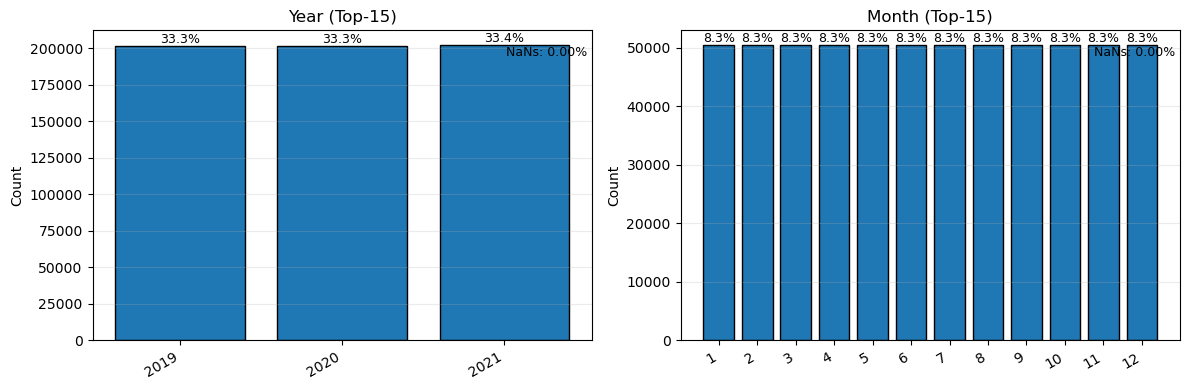

In [32]:
plot_bar_chart_top15(flights_db, discrete_time_features, ncols=2, rotate_xticks=30)

**Year:** 
- Bars are almost the same for all years: ~33.3%
- Each year contributes almost the same number of rows. 

**Month:**
- Distribution is perfectly uniform: ~8.3% for each month.
- Months are evenly represented as well. 

## Outliers:

In [33]:
def boxplot_grid(df, cols, ncols=3, figsize=(14, 8), showfliers=True):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax = axes[i]
        s = df[col].astype(float)
        ax.boxplot(s.dropna().values, vert=True, showmeans=False, showfliers=showfliers)
        ax.set_title(f"Boxplot of {col}")
        ax.set_xticks([])                 
        ax.set_ylabel(col)
        ax.grid(axis="y", alpha=0.25)

    # Hide unused subplot:
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

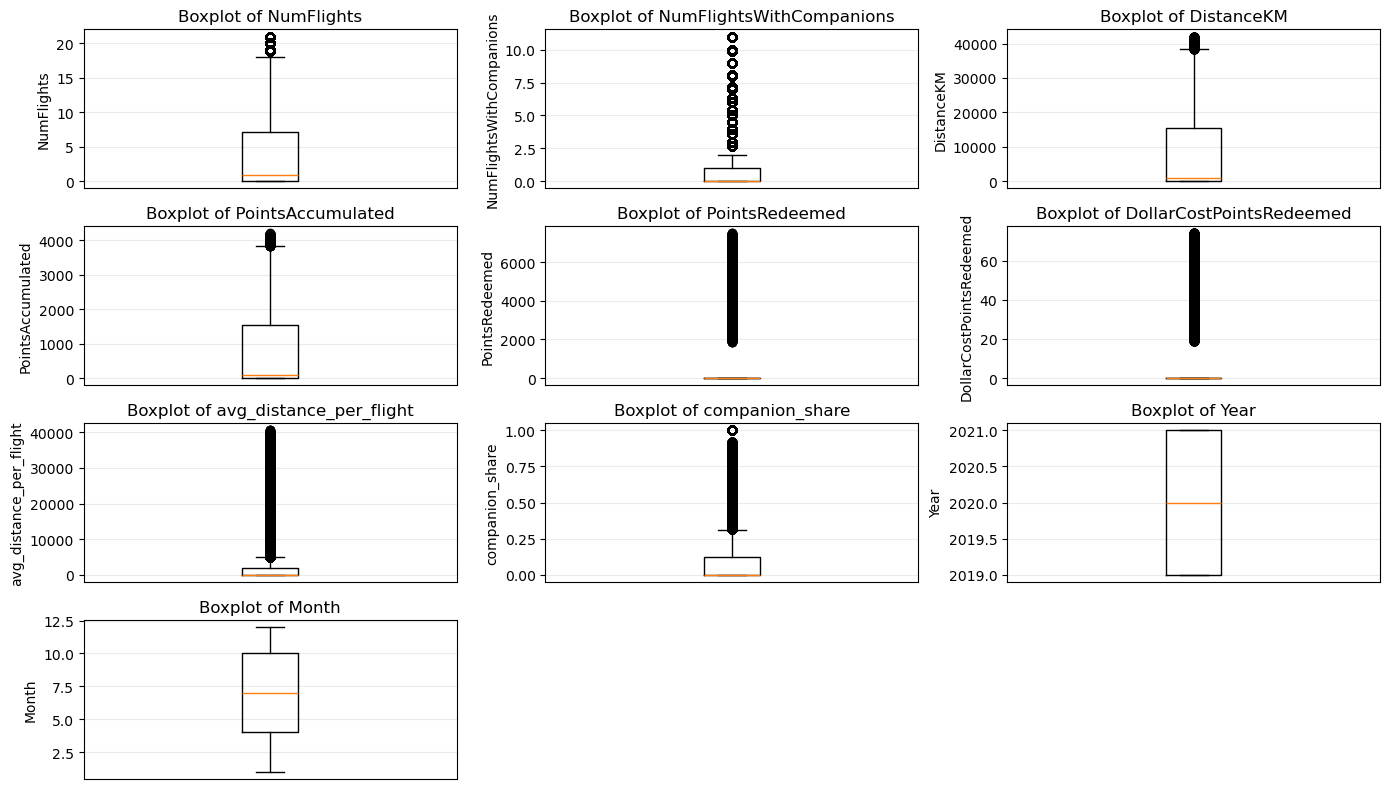

In [34]:
boxplot_grid(flights_db, numeric_features, ncols=3, figsize=(14, 8), showfliers=True)

**NumFlights** 
- The box shows a very low median (~0–1) with the lower quartile at 0 and a tight IQR near small values. Whiskers stretch high with many dots up to ~21. Clear right-skew and heavy zero inflation. 
- Outliers: High values (10–21) are legitimate heavy-travel months

**NumFlightsWithCompanions:**
- Median at 0 with a compact IQR close to zero. Long upper whisker and scattered points to ~11. Right-skew distribution.
- Outliers: Upper tail reflects group/holiday travel, not errors.

**DistanceKM:**
- Low median with wide IQR and a very long upper whisker. dense outliers up to ~42k km. Strong right tail typical of aviation (short-distance common, long-distance rare).
- Outliers: Valid long-distance months.

**PointsAccumulated:**
- Mirrors DistanceKM: low median, wide IQR, long right tail to ~4,200.
- Outliers: Same interpretation as distance, values are valid. 
- Since points = distance, we can treat one of the pair as redundant.

**PointsRedeemed:**
- Median and IQR = 0. a dense vertical region of points between ~2,000 and ~7,500. Extremely zero-inflated with spikes.
- Outliers: These “high” values are the events of interest (redemptions), not errors.

**DollarCostPointsRedeemed:**
- Same shape as PointsRedeemed.
- Outliers: Valid and linked to points. 
- Since DollarCostPointsRedeemed = PointsRedeemed, we can treat one of the pair as redundant.

**avg_distance_per_flight:**
- Median close to zero with an extremely long right tail. 
- Outliers: Many extreme dots (some very large) due to division by very small flight counts.

**companion_share:**
- Median near 0; IQR close to 0; many dots between 0.25-1 with a clear stack at 1.0 (all flights with companions).
- Outliers: High shares are legitimate behavior.

**Year:**
- Range between 2010-2021. 
- Outliers: No outliers.

**Month:**
- Range between 1-12. 
- Outliers: No outliers.

### Multivariate Analysis:

### Numerical x Numerical features:

In [35]:
def plot_pairwise_numeric(df, metric_features, title="Pairwise Relationship of Numerical Variables"):
    # Style and grid:
    sns.set_theme(style="ticks", rc={
        "axes.grid": True,
        "grid.color": ".9",
        "grid.linestyle": "-",
        "axes.spines.right": False,
        "axes.spines.top": False,
    })

    g = sns.pairplot(
        data=df[metric_features],
        diag_kind="hist",
        height=3.2,       
        aspect=1.0,
        corner=False,
        plot_kws=dict(
            s=14,         
            alpha=0.45,   
            linewidth=0.25,
            edgecolor="black",  
            rasterized=True     
        ),
        diag_kws=dict(
            bins=30,
            edgecolor="black",
            linewidth=0.2
        )
    )

    g.fig.suptitle(title, fontsize=18, y=1.02)
    plt.show()
    return g


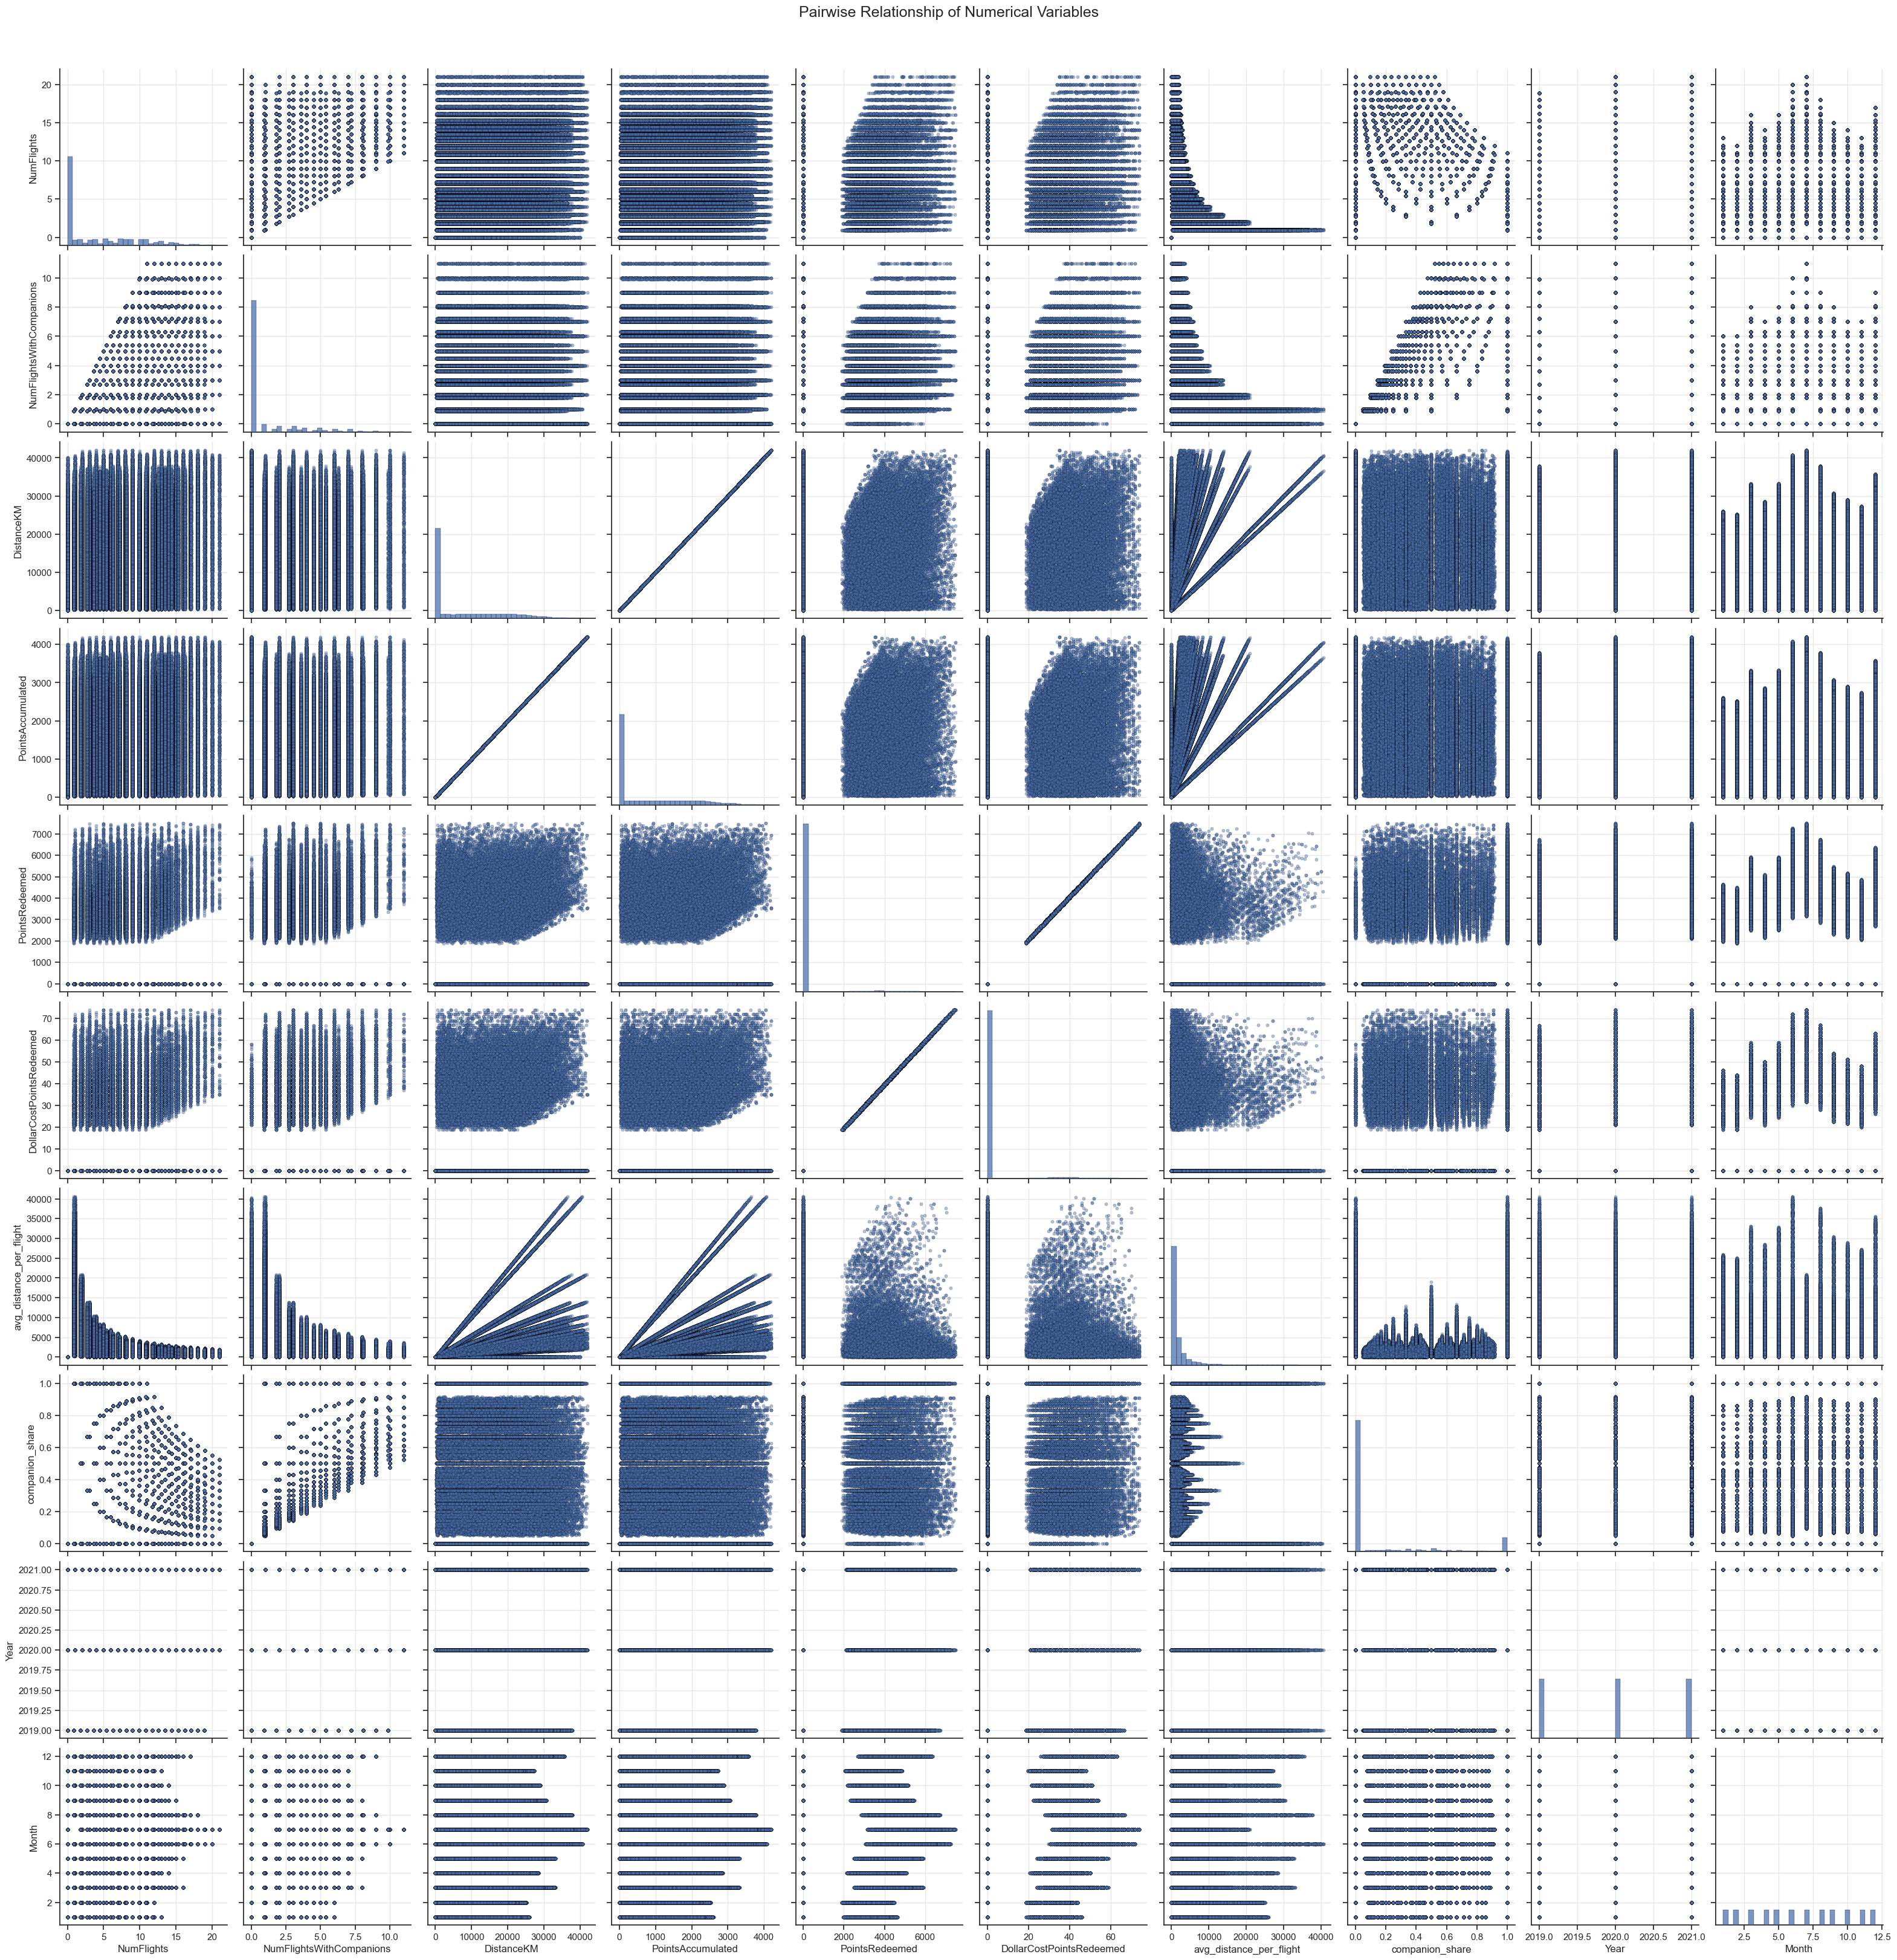

In [36]:
plot_pairwise_numeric(flights_db, numeric_features)

- **DistanceKM, PointsAccumulated:**
PointsAccumulated ~ linear in DistanceKM. These might be redundant features. Same distribution.

- **DollarCostPointRedeemed, PointsRedeemed:**
PointsAccumulated ~ linear in DistanceKM. These might be redundant features. Same distribution.

- **Heavy inactivity mass:**
All variables show a dense spike at 0: many customer-periods without flights or redemptions.

- **Flights vs distance:**
NumFlights shows vertical bands (integers) with wide DistanceKM spread: long-haul vs short-haul length matters more than the number of flights for point earn.

- **Companions are infrequent:**
NumFlightsWithCompanions ≤ NumFlights (triangular shape) with a strong pileup at 0 companions.

- **Earn vs redeem decoupled in time:**
Many records with PointsAccumulated > 0 but PointsRedeemed = 0: members tend to hoard and redeem sporadically; redemption events are not tightly tied to the same period’s earn.

### Correlation matrix:

#### Spearman:

Handles skewness and outliers better than Pearson:

In [37]:
def plot_corr_heatmap(df, metric_features, method):
    
    fig = plt.figure(figsize=(10, 8)) 
    corr = df[metric_features].corr(method)
    sns.heatmap(data=corr, annot=True, )

    plt.show()

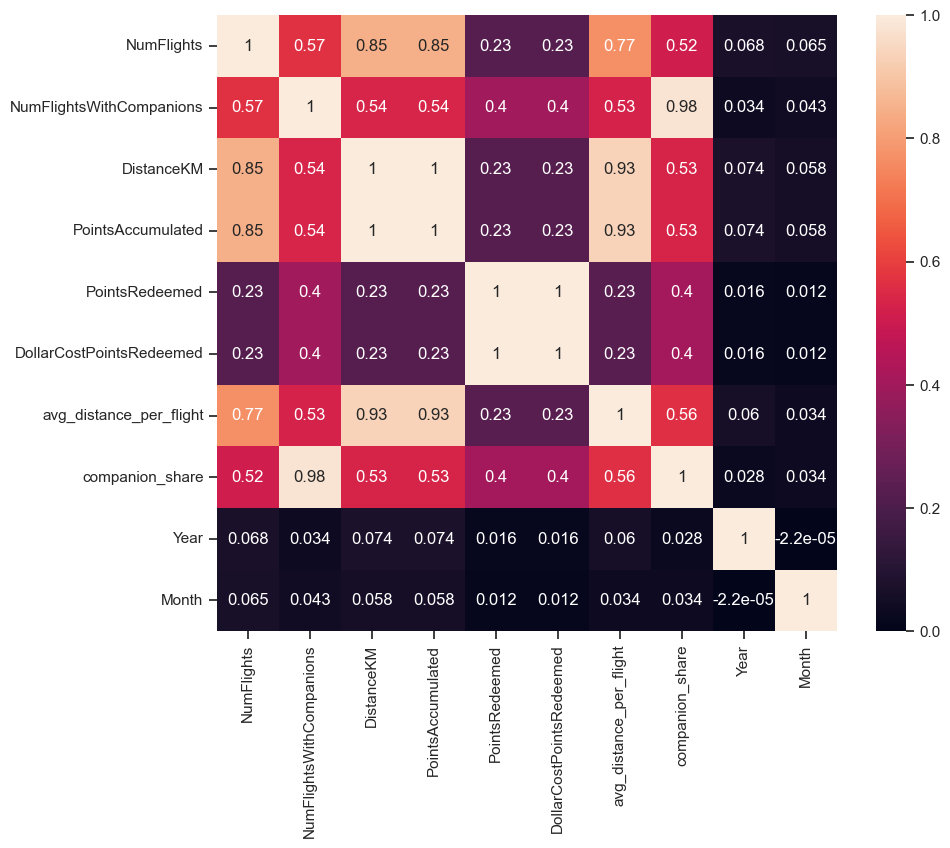

In [38]:
plot_corr_heatmap(flights_db, numeric_features, method='spearman')

**0.9-1.00 (Very strong positive correlation):**
- **DistanceKM, PointsAccumulated = 1.00;**
    - More distance, more points accumulated as expected. 
    - Redundant features.
       
- **PointsRedeemed, DollarCostPointsRedeemed = 1.00.**
    - More points redeemed, more DollarCostPointsRedeemed as expected. 
    - Redundant features.

- **DistanceKM,  avg_distance_per_flight = 0.93**   
    - More distance, more avg_distance_per_flight as expected. 
    - Redundant features.
    
**0.70–0.90 (strong positive correlation):**
- **NumFlights, DistanceKM = 0.85;**
- **NumFlights, PointsAccumulated ≈ 0.85**
    - More flights, more distance, more points as expected.
    
    
**0.50-0.70 (moderate positive correlation):**
- **NumFlights, NumFlightsWithCompanions = 0.57**
- **NumFlights, companion_share = 0.52**
    - As number of flights grows, companion travel rises.
    - Months with more flying are more likely to be with companions.
    
- **DistanceKM / PointsAccumulated, companion_share = 0.53**
    - Longer-distance months are more companion-oriented, consistent with family/holiday trips.

- **NumFlightsWithCompanions, DistanceKM** = 0.54
- **NumFlightsWithCompanions, PointsAccumulated** = 0.54 
    — Flights with companions tend to be higher-distance/earn.

**0.40–0.50 (low–moderate correlation):**
- **NumFlightsWithCompanions, PointsRedeemed = 0.40**
- **companion_share, PointsRedeemed = 0.40**
- **companion_share ↔ avg_distance_per_flight ≈ 0.56**
    - Redemptions co-occur somewhat with companion travel. The effect size is modest.

**0.20–0.30 (weak correlation):**
- **PointsRedeemed, NumFlights / DistanceKM / PointsAccumulated = 0.23**

**0 with calendar variables:**
- **Year / Month with most metrics = 0.03–0.08**



### Active customers over time:

In [39]:
def plot_active_rate(df, date_field='YearMonthDate'):
    dt = pd.to_datetime(df[date_field], errors='coerce')
    tmp = df.loc[dt.notna()].assign(__dt=dt, __active=(df['NumFlights'] > 0).astype(int))
    tmp = tmp.assign(__period=tmp['__dt'].dt.to_period('M'))  

    # one record per (customer, month)
    cust_month = tmp.groupby(['__period', 'Loyalty#'], as_index=False)['__active'].max()

    # monthly aggregates + rate
    monthly = (cust_month.groupby('__period', as_index=False)
                          .agg(active_customers=('__active', 'sum'),
                               total_customers=('Loyalty#', 'nunique')))
    monthly['active_rate'] = monthly['active_customers'] / monthly['total_customers']
    monthly['YearMonth'] = monthly['__period'].dt.to_timestamp()
    monthly = monthly.sort_values('YearMonth', ignore_index=True)

    ax = monthly.set_index('YearMonth')['active_rate'].plot(figsize=(12,4))
    ax.set_title('Active customer rate over time (NumFlights > 0)')
    ax.set_xlabel('')
    ax.set_ylabel('Active rate')
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(alpha=0.3)
    plt.tight_layout()
    return ax, monthly

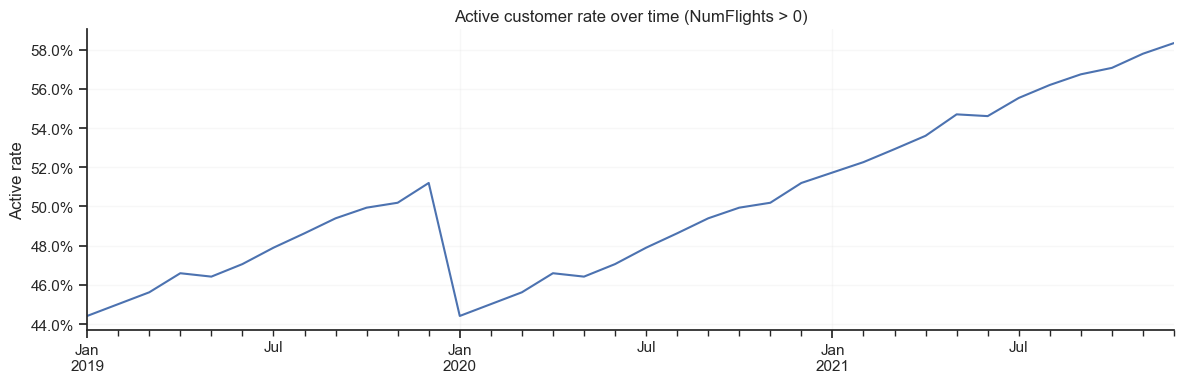

In [40]:
ax, monthly = plot_active_rate(flights_db, date_field='YearMonthDate') 

- **This timeseries represents the share of customers who flew each month.**
- **Active customer rate rises from ~44% in early-2019 to ~51% by late-2019, drops sharply around Jan 2020 (44-45%), this shock is consistent with the pandemic onset. Then it recovers through 2020 and accelerates in 2021, indicating stronger customer engagement.**
- **Seasonality is limited, the dominant pattern is a dip in early 2020 followed by sustained growth.**